Intenta aplicar lo aprendido con las lecciones de ingeniería de propiedades con el conjunto de datos de Titanic disponible en Kaggle. Este dataset es accesible y contiene una mezcla de tipos de datos categóricos y numéricos, lo que lo hace perfecto para ejercitar diversas técnicas de ingeniería de propiedades. La tarea consiste en predecir la supervivencia de los pasajeros del Titanic utilizando machine learning.

Tareas Específicas:

1. Análisis Exploratorio de Datos (EDA): Buscar valores faltantes e identifica las posibles relaciones entre las características y la variable objetivo.

2. Limpieza de Datos: Basándose en el EDA debes tratar los valores faltantes y corregir posibles errores en los datos

3. Construye un modelo base para poder comparar sus resultados con otros después de aplicar ingeniería de propiedades.

4.  Elimina las características irrelevantes y prueba el modelo, si no hay mejora no las quites. 

5. Aplicar técnicas de ingeniería de propiedades para transformar y crear nuevas características. Algunas sugerencias:

Crea una característica de "Tamaño de la familia" sumando las características SibSp (número de hermanos/cónyuges a bordo) y Parch (número de padres/hijos a bordo).
Extrae el título de la característica Name y usarlo para crear una nueva característica que pueda indicar el estatus social o el género, lo que podría influir en la supervivencia.
Crea bandas de edad para transformar la edad en una característica categórica, facilitando la captura de relaciones no lineales con la supervivencia.
Aplica target encoding a la característica Cabin considerando la letra de la cabina como una indicación de la cubierta, lo que podría afectar las posibilidades de supervivencia.

Prueba con random forest.

#### Cargar el datset del titanic

In [105]:
import pandas as pd

train = pd.read_csv('csv/train.csv')
test = pd.read_csv('csv/test.csv')
gender_submission = pd.read_csv('csv/gender_submission.csv')

df_titanic = pd.concat([train, test], ignore_index=True, sort=False)

# Fusiona gender_submission en df usando PassengerId como clave de unión
df_merged = pd.merge(df_titanic, gender_submission, on='PassengerId', how='left')

# Define una función para reemplazar NaN en 'Survived'
def fill_survived(row):
    if pd.isna(row['Survived']):
        passenger_id = row['PassengerId']
        survived_value = gender_submission.loc[gender_submission['PassengerId'] == passenger_id, 'Survived'].values[0]
        return survived_value
    else:
        return row['Survived']

# Aplica la función a la columna 'Survived' de df
df_titanic['Survived'] = df_titanic.apply(fill_survived, axis=1)

# Verifica los primeros registros para confirmar la sustitución
df_titanic


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,0.0,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
1305,1306,1.0,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
1306,1307,0.0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
1307,1308,0.0,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


#### Análisis Exploratorio de Datos (EDA)	


In [106]:
# pasar la columan 'Survived' a entero
df_titanic['Survived'] = df_titanic['Survived'].astype(int)

In [107]:
# buscar valores nulos
df_titanic.isnull().sum()

PassengerId       0
Survived          0
Pclass            0
Name              0
Sex               0
Age             263
SibSp             0
Parch             0
Ticket            0
Fare              1
Cabin          1014
Embarked          2
dtype: int64

In [108]:
# le asignará la moda porque desde desde Southhampton embarcaron la mayoría de los pasajeros, y tuvieron una tasa de supervivencia de 70%
df_titanic['Embarked'].fillna(df_titanic['Embarked'].mode()[0], inplace=True)

df_titanic.isnull().sum()

PassengerId       0
Survived          0
Pclass            0
Name              0
Sex               0
Age             263
SibSp             0
Parch             0
Ticket            0
Fare              1
Cabin          1014
Embarked          0
dtype: int64

In [109]:
# le asignaremos la mediana por ser menos sensible a los valores extremos
df_titanic['Fare'].fillna(df_titanic['Fare'].median(), inplace=True)

df_titanic.isnull().sum()

PassengerId       0
Survived          0
Pclass            0
Name              0
Sex               0
Age             263
SibSp             0
Parch             0
Ticket            0
Fare              0
Cabin          1014
Embarked          0
dtype: int64

In [110]:
# veremos la edad media de hombres y mujeres y se la asignaré a los valores nulos en esta primera toma de contacto
age_by_sex = df_titanic.groupby('Sex')['Age'].mean()

# Rellenar los valores nulos en 'Age' con la media por género
df_titanic['Age'] = df_titanic.apply(lambda row: age_by_sex[row['Sex']] if pd.isnull(row['Age']) else row['Age'], axis=1)

# Verificar si hay valores nulos después de la imputación
df_titanic.isnull().sum()

PassengerId       0
Survived          0
Pclass            0
Name              0
Sex               0
Age               0
SibSp             0
Parch             0
Ticket            0
Fare              0
Cabin          1014
Embarked          0
dtype: int64

In [111]:
# y por último cabina, se le asignará un nuevo valor 'NA' 
df_titanic['Cabin'].fillna('NA', inplace=True)

df_titanic.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

Vale ahora que ya no tenemos nulos veremos la relación entre las variables y la variable objetivo, con el fin de ver si hay alguna relación entre ellas. Se usará mutuals information.

In [112]:
from sklearn.feature_selection import mutual_info_classif

# ver la influencía del target con las características con el mutual information
df_titanic2 = df_titanic.copy()
target = df_titanic2.pop('Survived')

for colname in df_titanic2.select_dtypes("object"):
    df_titanic2[colname], _ = df_titanic2[colname].factorize()

discrete_features = df_titanic2.dtypes == int

In [113]:
def make_mi_scores(X, y, discrete_features):
    mi_scores = mutual_info_classif(X, y, discrete_features=discrete_features)
    mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores

mi_scores = make_mi_scores(df_titanic2, target, discrete_features)

mi_scores

Sex            0.267268
Fare           0.121111
Ticket         0.068107
Age            0.066043
Pclass         0.037245
Cabin          0.033269
SibSp          0.024849
Parch          0.019037
Embarked       0.015076
PassengerId    0.004263
Name           0.004131
Name: MI Scores, dtype: float64

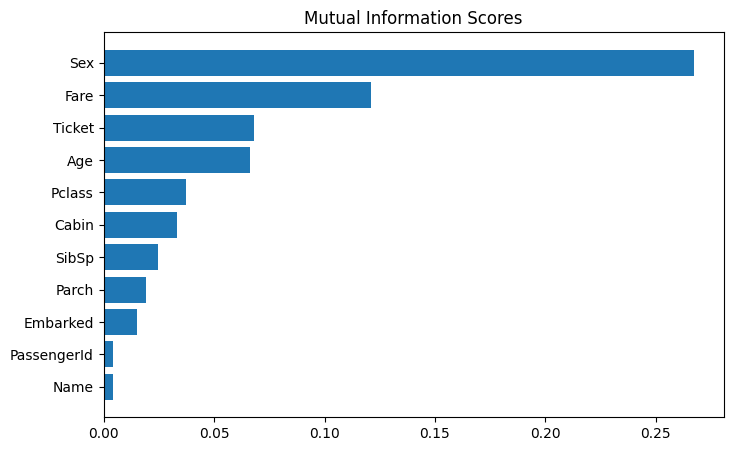

In [114]:
import matplotlib.pyplot as plt
import numpy as np

# Dibujar el gráfico de barras
def plot_mi_scores(scores):
    scores = scores.sort_values(ascending=True)
    width = np.arange(len(scores))
    ticks = list(scores.index)
    plt.barh(width, scores)
    plt.yticks(width, ticks)
    plt.title("Mutual Information Scores")

plt.figure(dpi=100, figsize=(8, 5))
plot_mi_scores(mi_scores)

Podemos observar que las 2 variables que tienen más relación con la variable objetivo son el sexo y el precio del billete, por lo que se puede decir que estas variables son las más importantes para predecir la supervivencia de los pasajeros del Titanic.

Se creará ahora un modelo base para poder comparar los resultados con otros modelos después de aplicar ingeniería de propiedades.

Aquí no se ha estandaraizado las variables ni se ha hecho ninguna transformación.

In [115]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

model = RandomForestClassifier(random_state = 42)
scores = cross_val_score(model, df_titanic2, target).mean()
scores

0.8595419847328245

Ahora vamos a eliminar algunas variables que no apartan nada como el lugar de embarque que tiene 0 relación con la variable objetivo. Para ver si mejora el modelo.

In [116]:
df_titanic2.drop(['Embarked'], axis=1, inplace=True)

scores = cross_val_score(model, df_titanic2, target).mean()
scores

0.8618320610687021

In [117]:
df_titanic2.drop(['Name'], axis=1, inplace=True)

scores = cross_val_score(model, df_titanic2, target).mean()
scores

0.8648796466906494